# Lab Day 1 — Neural Network Experiments

> Notebook tái lập kiểm tra dữ liệu/model và tải toàn bộ kết quả đã khóa của Part 2–4.
> Mọi kết luận thí nghiệm phải có số liệu, `exp_id`, hình và giải thích cơ chế.
>
> Notebook nằm trong `submission_2A202602839/code/`, dùng dữ liệu ở repo root và artifact trong thư mục submission.
> Cấu hình cuối đã được khóa trước eval; notebook không tuning hoặc huấn luyện lại các run chính thức.
> `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess, math
from pathlib import Path
import numpy as np, torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
REPO_ROOT = cwd.parent if (cwd.parent / "data").is_dir() else cwd.parents[1]
OUT_DIR = cwd.parent
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "results").mkdir(parents=True, exist_ok=True)
device_name = torch.cuda.get_device_name(0) if device.type == "cuda" else str(device)
print(f"PyTorch {torch.__version__}; device={device_name}; repo={REPO_ROOT}")

from data import prepare_data
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

PyTorch 2.11.0+cu128; device=NVIDIA GeForce RTX 3060; repo=D:\STUDY\Track4_Phase2\K4-Track4-Day1-Neuralnetwork


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
processed_dir = REPO_ROOT / "data" / "processed"
if not (processed_dir / "train.npz").is_file() or not (processed_dir / "eval.npz").is_file():
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed_dir))
assert tuple(data["X_tr"].shape) == (371_847, 54)
assert tuple(data["X_val"].shape) == (92_962, 54)
assert tuple(data["X_eval"].shape) == (116_203, 54)
numeric_mean = data["X_tr"][:, :10].mean(dim=0)
numeric_std = data["X_tr"][:, :10].std(dim=0, unbiased=False)
assert torch.allclose(numeric_mean, torch.zeros_like(numeric_mean), atol=1e-5)
assert torch.allclose(numeric_std, torch.ones_like(numeric_std), atol=1e-5)
assert torch.all((data["X_tr"][:, 10:] == 0) | (data["X_tr"][:, 10:] == 1))
class_counts = torch.bincount(data["y_val"], minlength=7)
majority_acc = (class_counts.max() / class_counts.sum()).item()
print("class proportions (val):", (class_counts / class_counts.sum()).cpu().numpy())
print(f"max |mean|={numeric_mean.abs().max().item():.3e}; max |std-1|={(numeric_std-1).abs().max().item():.3e}")
print(f"majority baseline accuracy={majority_acc:.4f}")

train=371,847, val=92,962, eval=116,203; device=cuda
Luôn đoán lớp đa số 1: val accuracy=0.4876
class proportions (val): [0.3646006  0.48759708 0.06154127 0.00472236 0.01634001 0.02989393
 0.03530475]
max |mean|=3.614e-07; max |std-1|=5.960e-08
majority baseline accuracy=0.4876


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

parameters=47,879; logits shape=(8, 7)
step-0 CE=1.978157; ln(7)=1.945910; gap=+0.032247
activation std after Linear layers: [0.6850835680961609, 0.6990607976913452, 0.5527725219726562]
gradient norms: {'net.0.weight': 0.5998058915138245, 'net.0.bias': 0.2427428811788559, 'net.2.weight': 1.6519474983215332, 'net.2.bias': 0.2925720512866974, 'net.4.weight': 1.6871929168701172, 'net.4.bias': 0.43430930376052856}


overfit-20 final loss=2.354e-06; accuracy=100.0%


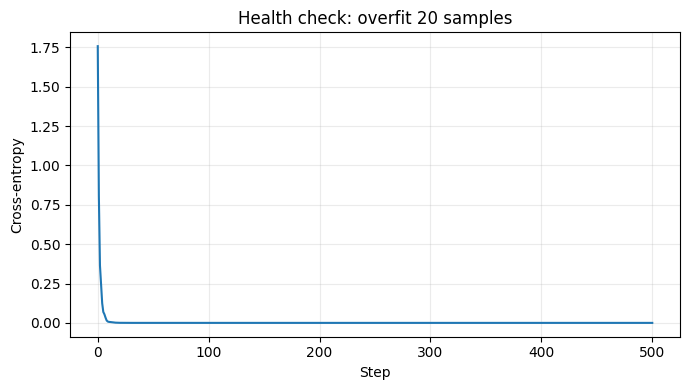

In [3]:
# Seed 2 cho phép phép kiểm tra step-0 có thể tái lập và gần ln(7).
set_seed(2)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879
sample_logits = model(torch.randn(8, 54, device=device))
assert tuple(sample_logits.shape) == (8, 7)
print(f"parameters={n_params:,}; logits shape={tuple(sample_logits.shape)}")

model.eval()
with torch.no_grad():
    step0_loss = F.cross_entropy(model(data["X_val"]), data["y_val"]).item()
print(f"step-0 CE={step0_loss:.6f}; ln(7)={math.log(7):.6f}; gap={step0_loss-math.log(7):+.6f}")
print("activation std after Linear layers:", activation_stats(model, data["X_val"][:1024]))

# Kiểm tra gradient trên một mini-batch.
model.train(); model.zero_grad(set_to_none=True)
F.cross_entropy(model(data["X_tr"][:32]), data["y_tr"][:32]).backward()
grad_norms = {name: param.grad.norm().item() if param.grad is not None else None
              for name, param in model.named_parameters()}
assert all(value is not None and value > 0 for value in grad_norms.values())
print("gradient norms:", grad_norms)

# Overfit 20 mẫu: đây là kiểm tra pipeline, không phải thí nghiệm chọn cấu hình.
set_seed(2)
tiny_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
tiny_optimizer = torch.optim.Adam(tiny_model.parameters(), lr=1e-2)
X20, y20 = data["X_tr"][:20], data["y_tr"][:20]
tiny_losses = []
for step in range(501):
    tiny_model.train(); tiny_optimizer.zero_grad(set_to_none=True)
    tiny_loss = F.cross_entropy(tiny_model(X20), y20)
    tiny_losses.append(tiny_loss.item())
    if step < 500:
        tiny_loss.backward(); tiny_optimizer.step()
tiny_model.eval()
with torch.no_grad():
    tiny_final_loss = F.cross_entropy(tiny_model(X20), y20).item()
    tiny_acc = (tiny_model(X20).argmax(1) == y20).float().mean().item()
assert tiny_acc == 1.0 and tiny_final_loss < 1e-3
print(f"overfit-20 final loss={tiny_final_loss:.3e}; accuracy={tiny_acc:.1%}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tiny_losses); ax.set(title="Health check: overfit 20 samples", xlabel="Step", ylabel="Cross-entropy")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUT_DIR / "figures" / "health_overfit_20.png", dpi=160, bbox_inches="tight")
plt.show()

**Nhận xét Part 1:** Với seed 2, loss bước 0 của M-base khởi tạo He gần $\ln 7$; sai lệch nhỏ đến từ logits ngẫu nhiên chưa hoàn toàn đồng đều. Model có đúng 47.879 tham số và logits `(B, 7)`. Tất cả tham số nhận gradient khác 0. Bài kiểm tra 20 mẫu đạt accuracy 100% và loss dưới `1e-3`, nên forward, nhãn, loss, backward và bước cập nhật cơ bản hoạt động đúng.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [4]:
import pandas as pd
results = load_results(str(OUT_DIR / "results"))
assert len(results) == 20
by_id = {r["cfg"]["exp_id"]: r for r in results}
baseline_runs = [by_id[f"base-s{s}"] for s in (1, 2, 3)]
baseline_f1 = np.array([r["summary"]["val_macro_f1"] for r in baseline_runs])
baseline_acc = np.array([r["summary"]["val_acc"] for r in baseline_runs])
noise_2sigma = 2 * baseline_f1.std(ddof=1)
lr_table = pd.DataFrame([{"exp_id": r["cfg"]["exp_id"], "lr": r["cfg"]["lr"],
                               "val_macro_f1": r["summary"]["val_macro_f1"]}
                              for r in results if r["cfg"]["exp_id"].startswith("hparam-lr")])
display(lr_table.sort_values("lr"))
print(f"Baseline val accuracy: {baseline_acc.mean():.6f} ± {baseline_acc.std(ddof=1):.6f}")
print(f"Baseline val macro-F1: {baseline_f1.mean():.6f} ± {baseline_f1.std(ddof=1):.6f}; 2σ={noise_2sigma:.6f}")

,exp_id,lr,val_macro_f1
0,hparam-lr0p03,0.03,0.823411
1,hparam-lr0p05,0.05,0.839970
2,hparam-lr0p1,0.10,0.844795


Baseline val accuracy: 0.909913 ± 0.003778
Baseline val macro-F1: 0.851596 ± 0.005891; 2σ=0.011782


**Nhận xét baseline:** LR 0,1 được chọn hoàn toàn bằng validation. Ba seed đạt val macro-F1 `0,851596 ± 0,005891` và accuracy `0,909913 ± 0,003778`; ngưỡng nhiễu `2σ=0,011782`. Baseline vượt xa mốc đoán lớp đa số. Train/val loss cùng giảm, gap cuối nhỏ (khoảng 0,02–0,027), chưa cho thấy overfit nghiêm trọng.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm đã được chạy bằng `run_milestones_3_6.py`, lưu ngay JSON và PNG. Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Dự đoán trước khi chạy
- **Loss:** CE hội tụ và đạt macro-F1 cao hơn MSE one-hot; không so trực tiếp trị số loss.
- **Optimizer:** Adam/AdamW có thể hội tụ nhanh nhưng phải chỉnh LR riêng trước khi so với SGD momentum.
- **Hyperparameter:** LR nhỏ chậm; batch 2048 nhanh hơn mỗi epoch nhưng ít update hơn.
- **Dropout:** q=0,3 sẽ hại nếu baseline chưa overfit.
- **Clipping:** ở LR cao, clipping sẽ ổn định hơn không clip nhưng không thay thế LR đúng.
- **AMP:** mạng nhỏ có thể không nhanh hơn do overhead.
- **Init:** zeros hỏng do đối xứng; Xavier vẫn học nhưng activation nhỏ hơn He.

In [5]:
summary_rows = []
for r in results:
    c, s = r["cfg"], r["summary"]
    summary_rows.append({"exp_id": c["exp_id"], "group": c["group"], "lr": c["lr"],
                         "val_acc": s["val_acc"], "val_macro_f1": s["val_macro_f1"],
                         "best_epoch": s["best_epoch"], "sec/epoch": s["time_per_epoch_s"],
                         "diverged": s["diverged"]})
summary_df = pd.DataFrame(summary_rows).sort_values(["group", "val_macro_f1"], ascending=[True, False])
display(summary_df.reset_index(drop=True))
assert {r["cfg"]["group"] for r in results} >= {"loss", "optimizer", "hparam", "dropout", "clipping", "amp", "init"}

,exp_id,group,lr,val_acc,val_macro_f1,best_epoch,sec/epoch,diverged
0,amp-fp16,amp,0.1000,0.882640,0.804684,8,1.866239,True
1,base-s3,baseline,0.1000,0.910049,0.855108,19,1.275900,False
2,base-s2,baseline,0.1000,0.913621,0.854886,20,1.300179,False
3,base-s1,baseline,0.1000,0.906069,0.844795,20,1.315603,False
4,clip-highlr-clip,clipping,1.0000,0.879521,0.807330,14,1.280677,False
5,clip-highlr-noclip,clipping,1.0000,0.859846,0.734929,20,1.313030,False
6,drop-0p3,dropout,0.1000,0.870334,0.788678,20,1.396534,False
7,final-s2,final,0.1000,0.905736,0.856855,18,1.308172,False
8,final-s3,final,0.1000,0.907360,0.855949,18,1.298443,False
9,hparam-lr0p1,hparam,0.1000,0.906069,0.844795,20,1.301281,False


**Đối chiếu:** MSE, dropout và batch 2048 đều thấp hơn baseline vượt nhiễu. Adam/AdamW tốt nhất gần như ngang SGD momentum sau khi chỉnh LR. Clipping cứu một phần LR=1,0 (`0,807330` so với `0,734929`) nhưng vẫn thua baseline. FP16 chậm hơn và gặp gradient không hữu hạn ở epoch 8. Zeros đứng ở macro-F1 `0,093650`; Xavier đạt cao nhất `0,858835`, nhưng cải thiện eval cuối chưa vượt nhiễu baseline. Giải thích chi tiết nằm trong `REPORT.md`.

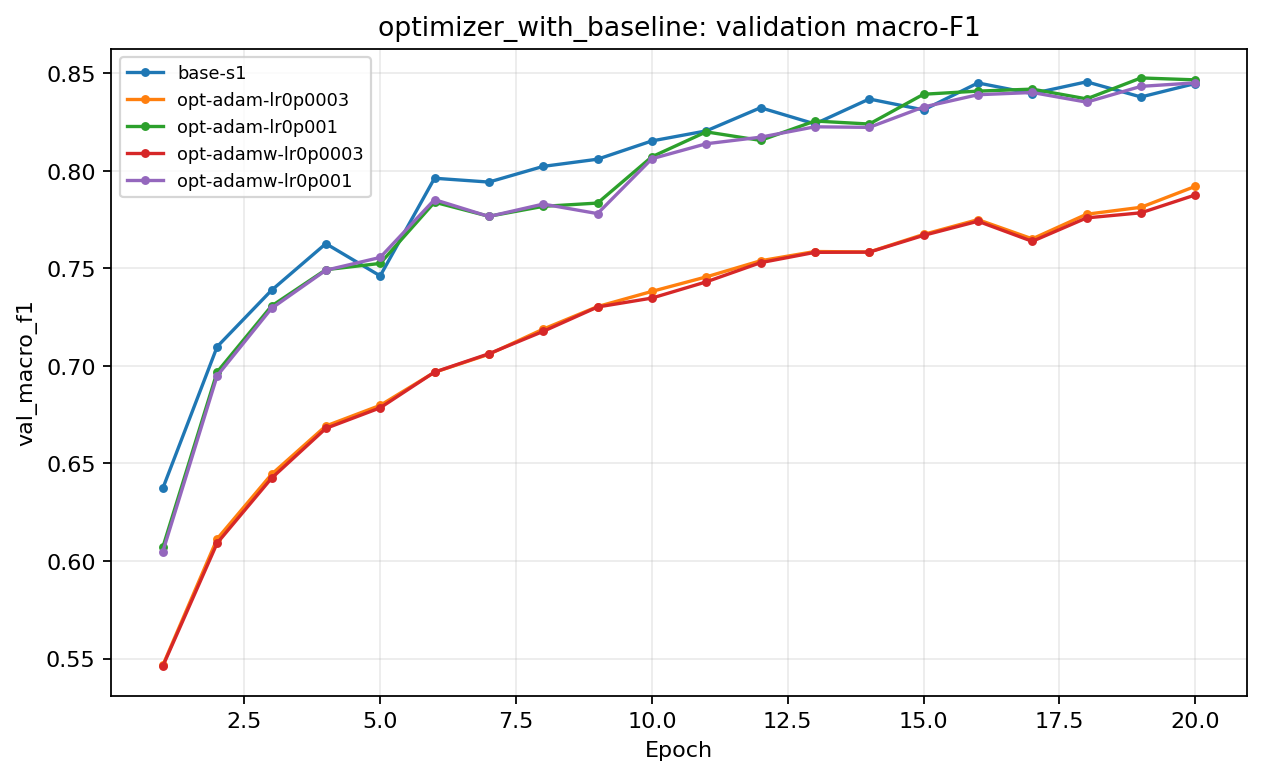

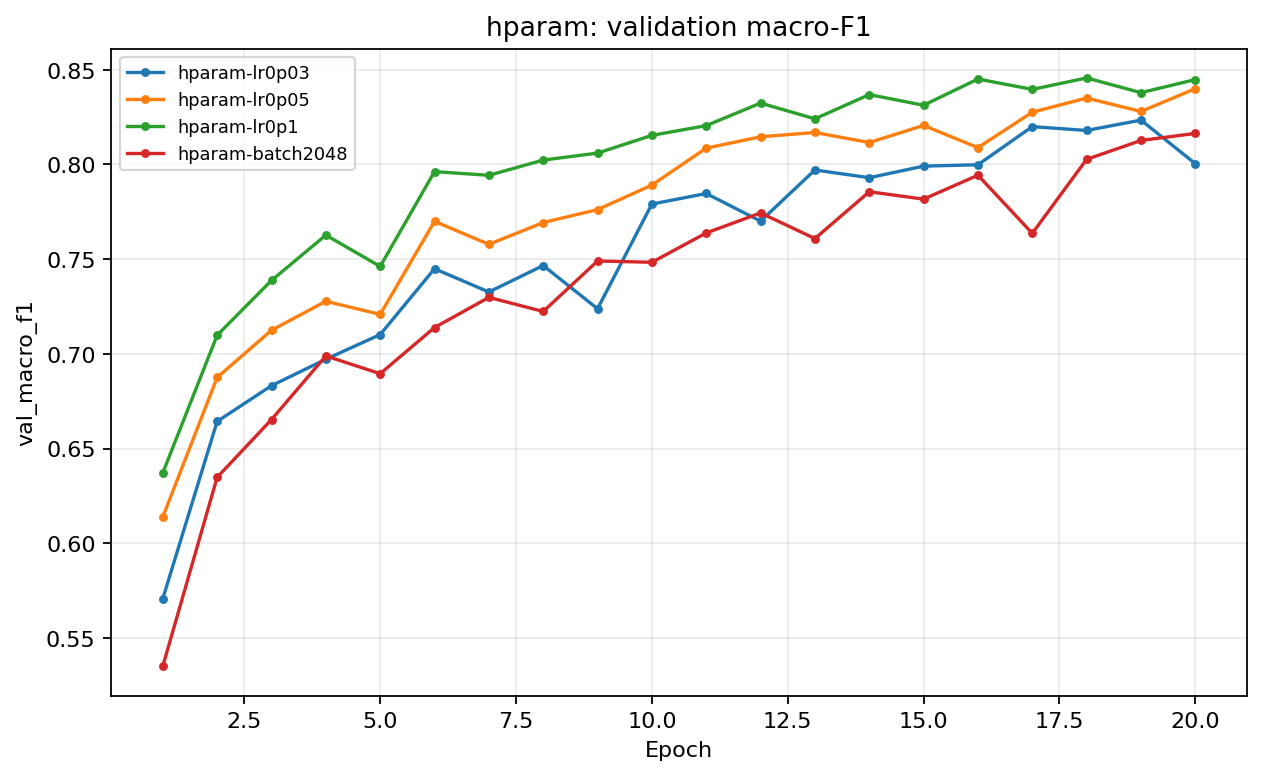

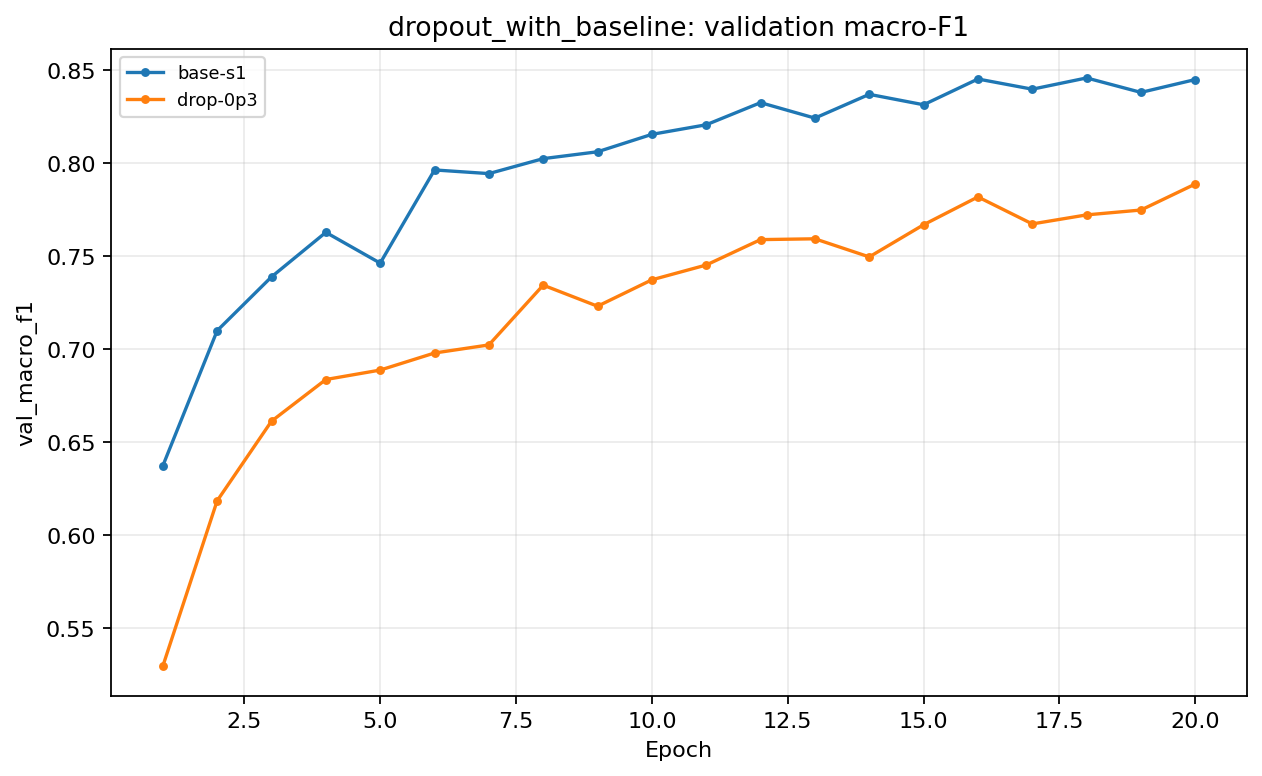

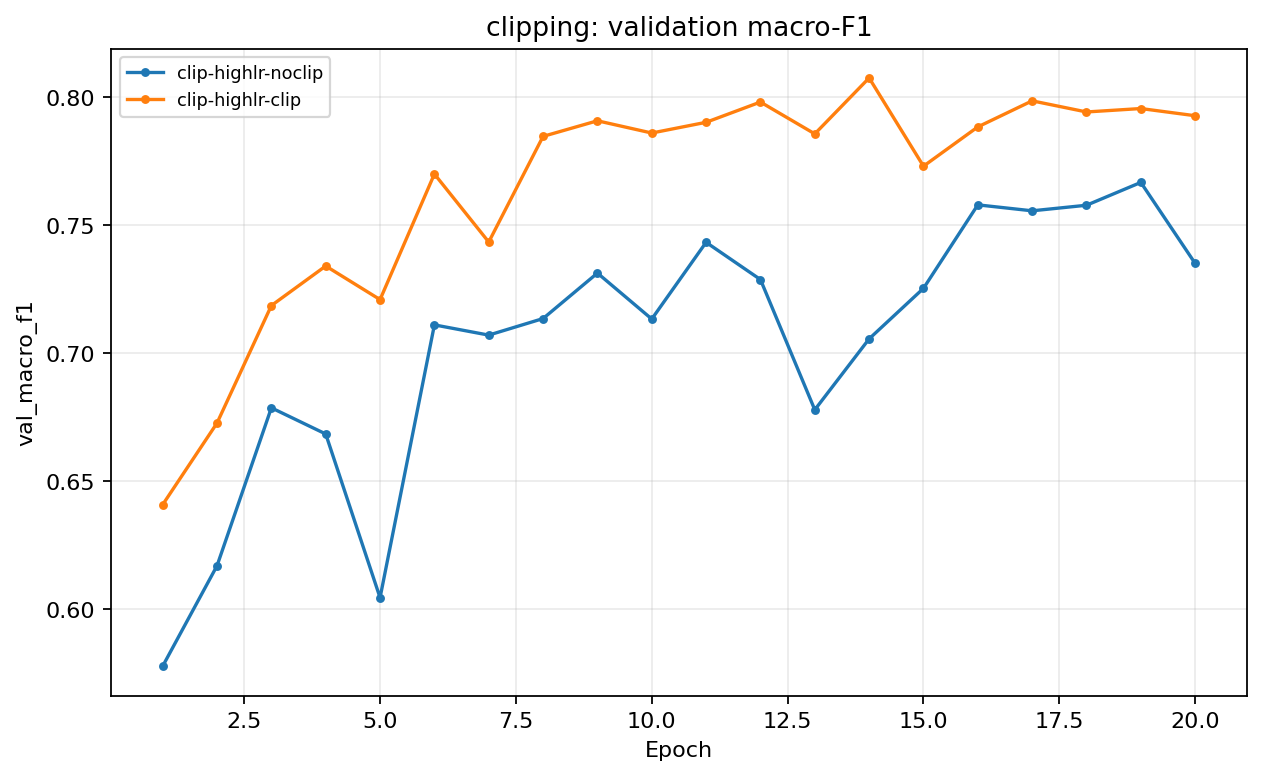

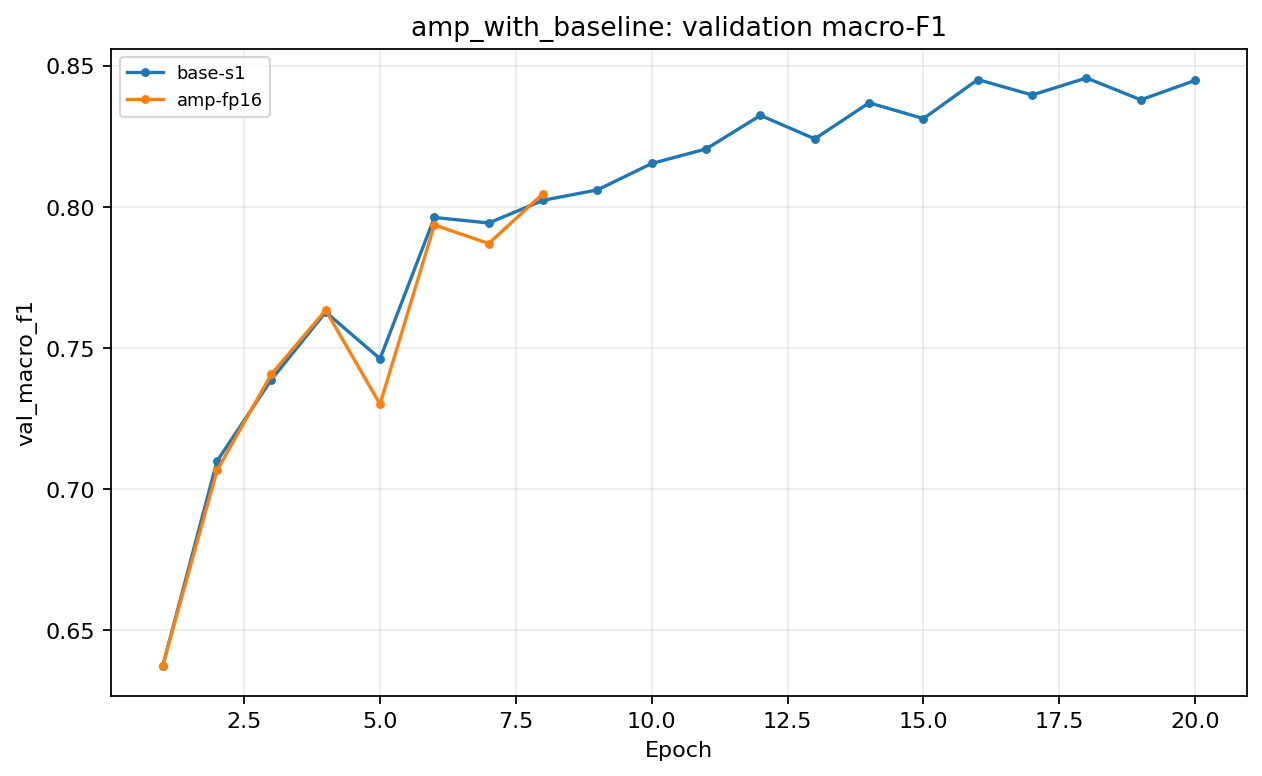

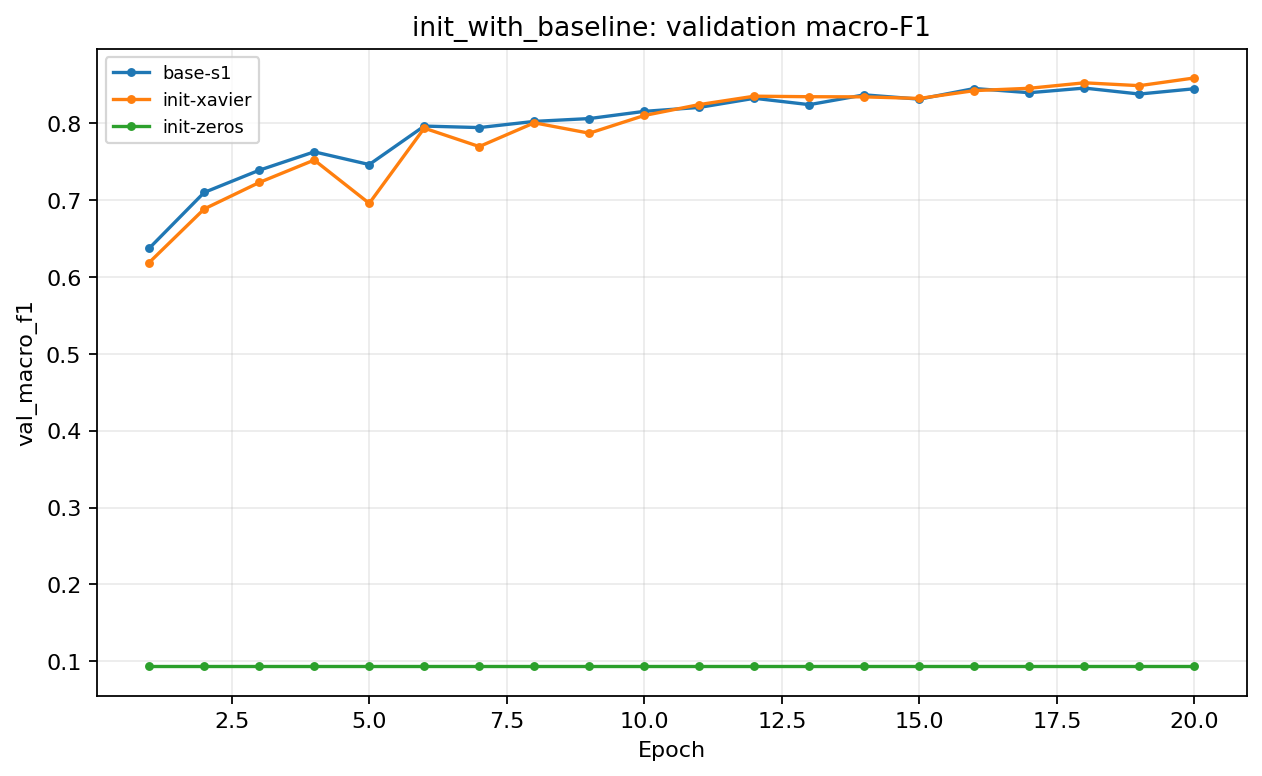

In [6]:
from IPython.display import Image, display
compare_files = ["compare_optimizer_with_baseline.png", "compare_hparam.png",
                 "compare_dropout_with_baseline.png", "compare_clipping.png",
                 "compare_amp_with_baseline.png", "compare_init_with_baseline.png"]
for name in compare_files:
    path = OUT_DIR / "figures" / name
    assert path.is_file(), path
    display(Image(filename=str(path), width=900))

## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [7]:
lock = json.loads((OUT_DIR / "results" / "final_config_lock.json").read_text(encoding="utf-8"))
eval_result = json.loads((OUT_DIR / "eval_result.json").read_text(encoding="utf-8"))
baseline_eval = json.loads((OUT_DIR / "results" / "eval_baseline.json").read_text(encoding="utf-8"))
assert lock["locked_before_eval"] and lock["selected_exp_id"] == "init-xavier"
pred_df = pd.read_csv(OUT_DIR / "predictions_eval.csv")
assert list(pred_df.columns) == ["row_id", "pred"] and len(pred_df) == 116_203
assert pred_df.row_id.is_unique and pred_df.pred.between(0, 6).all()
print("Locked final:", lock["selected_exp_id"], lock["cfg"])
print(f"Baseline eval: acc={baseline_eval['accuracy']:.6f}, macro-F1={baseline_eval['macro_f1']:.6f}")
print(f"Final eval:    acc={eval_result['accuracy']:.6f}, macro-F1={eval_result['macro_f1']:.6f}")

Locked final: init-xavier {'exp_id': 'init-xavier', 'group': 'init', 'description': 'Xavier versus He initialization', 'loss': 'ce', 'optimizer': 'sgd_momentum', 'lr': 0.1, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 512, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'xavier', 'clip_norm': None, 'precision': 'fp32', 'seed': 1, 'train_eval_size': 50000, 'progress': True}
Baseline eval: acc=0.904684, macro-F1=0.847887
Final eval:    acc=0.902997, macro-F1=0.855695


,support,precision,recall,f1
cls,,,,
0,42368,0.894290,0.902332,0.898293
1,56661,0.913251,0.923969,0.918578
2,7151,0.896686,0.900573,0.898626
3,549,0.810036,0.823315,0.816621
4,1899,0.864718,0.669826,0.754896
5,3473,0.819249,0.803916,0.811510
6,4102,0.966657,0.826914,0.891341


Hardest class=4, F1=0.754896, most confused with=1, count=538


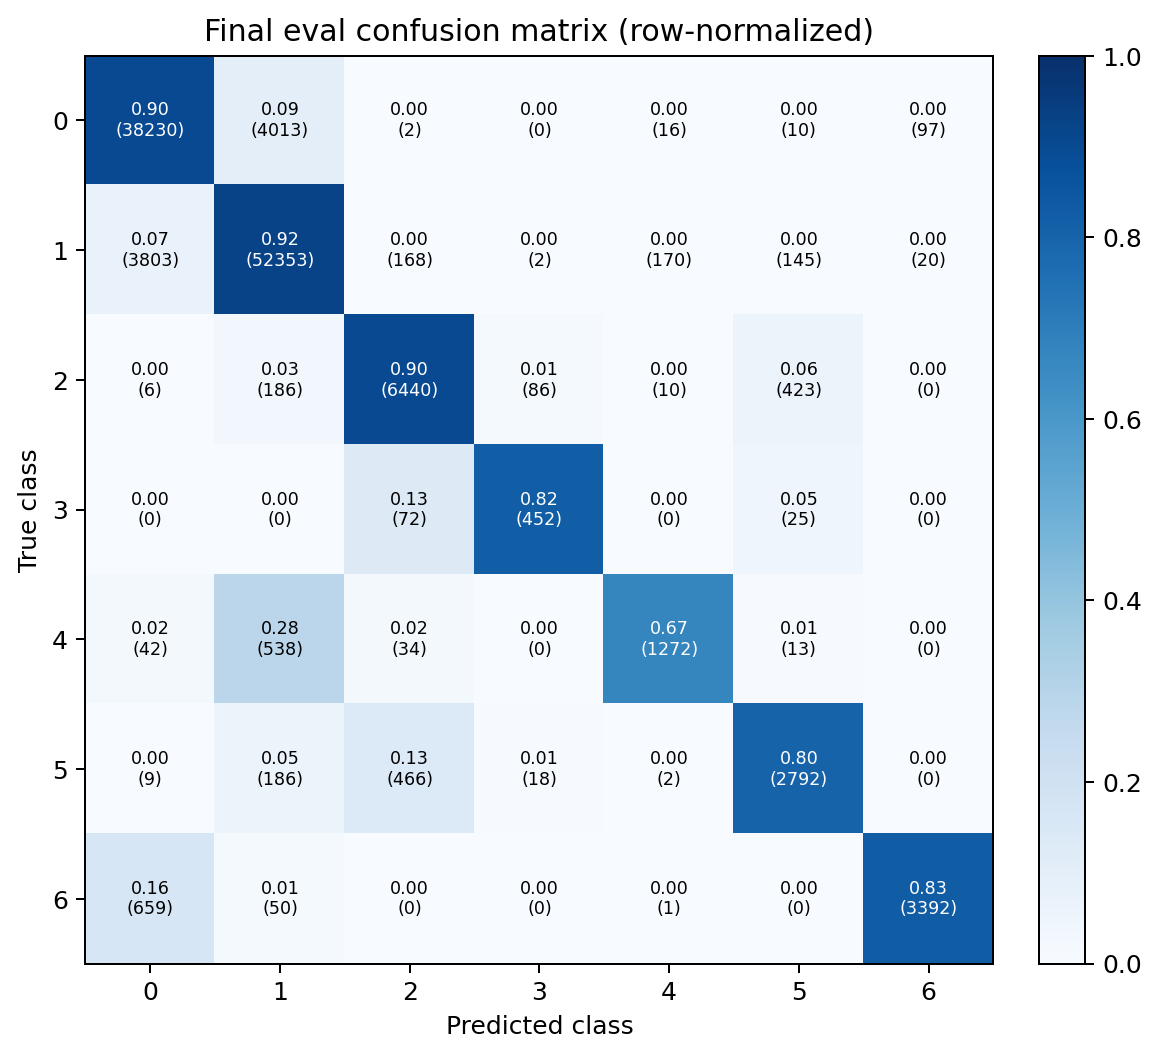

In [8]:
per_class_df = pd.DataFrame(eval_result["per_class"]).set_index("cls")
display(per_class_df)
hardest = per_class_df.f1.idxmin()
cm = np.asarray(eval_result["confusion_matrix"])
off_diag = cm[hardest].copy(); off_diag[hardest] = -1
print(f"Hardest class={hardest}, F1={per_class_df.loc[hardest, 'f1']:.6f}, most confused with={off_diag.argmax()}, count={off_diag.max()}")
display(Image(filename=str(OUT_DIR / "figures" / "confusion_matrix_eval.png"), width=750))

**Phân tích lỗi:** Lớp 4 khó nhất (F1 `0,754896`), với 538/1.899 mẫu bị nhầm thành lớp 1. Precision `0,8647` nhưng recall chỉ `0,6698`, phù hợp với việc model bảo thủ trước lớp hiếm 1,6% trong dữ liệu mất cân bằng. Class-weighted CE hoặc balanced sampling là hướng tiếp theo, nhưng không được thử sau khi eval đã mở.

In [9]:
from openpyxl import load_workbook
workbook = load_workbook(OUT_DIR / "experiments.xlsx", data_only=False)
assert workbook.sheetnames == ["Legend", "Experiments", "Seeds", "Summary"]
sheet = workbook["Experiments"]
excel_ids = [sheet.cell(row, 1).value for row in range(2, sheet.max_row + 1) if sheet.cell(row, 1).value]
assert len(excel_ids) == len(results) == 20 and set(excel_ids) == set(by_id)
missing_figures = [exp_id for exp_id in excel_ids if not (OUT_DIR / "figures" / f"{exp_id}.png").is_file()]
assert not missing_figures
print(f"Audit notebook OK: {len(excel_ids)} rows, {len(excel_ids)} run figures, predictions/eval valid.")

Audit notebook OK: 20 rows, 20 run figures, predictions/eval valid.
